## Query

In [135]:
import os
import pandas as pd
from pathlib import Path
print(f"Current working directory: {os.getcwd()}")

Current working directory: D:\projects\MateReview\notebooks


In [136]:
import pybliometrics
pybliometrics.scopus.init()

In [ ]:
# Scopus
from pybliometrics.scopus import ScopusSearch

# Define your query (same syntax as the Scopus search bar)
query = '''TITLE-ABS-KEY (
  ("hybrid model*" OR "physics-informed" OR "physics-guided" OR "theory-guided" OR "model calibration" OR "gr?y box model*" OR "semi-parametric" OR "informed machine learning" OR "residual model*" OR "data fusion" OR "dynamic discrepancy")
  AND
  ("machine learning" OR "neural network*" OR "transfer learning" OR "deep learning" OR "PINN*" OR "data-driven" OR "surrogate" OR "Gaussian process*" OR "universal approximator*")
  AND
  (physics OR mechanistic OR "first principles" OR "differential equation*" OR "conservation law*" OR "PDE" OR "ODE" OR "mass balance*" OR "energy balance*" OR "current knowledge" OR "computer simulation")
)
'''

# Perform the search
s = ScopusSearch(query, verbose=True)

# Convert the results to a list of dictionaries or a DataFrame
results_df = pd.DataFrame(s.results)

print(f"Found {len(results_df)} papers.")
results_df[['title', 'publicationName', 'doi']].head()

  ("hybrid model*" OR "physics-informed" OR "physics-guided" OR "theory-guided" OR "model calibration" OR "gr?y box model*" OR "semi-parametric" OR "informed machine learning" OR "residual model*" OR "data fusion" OR "dynamic discrepancy")
  AND
  ("machine learning" OR "neural network*" OR "transfer learning" OR "deep learning" OR "PINN*" OR "data-driven" OR "surrogate" OR "Gaussian process*" OR "universal approximator*")
  AND
  (physics OR mechanistic OR "first principles" OR "differential equation*" OR "conservation law*" OR "PDE" OR "ODE" OR "mass balance*" OR "energy balance*" OR "current knowledge" OR "computer simulation")
)
":


  2%|▏         | 17/694 [00:28<19:28,  1.73s/it]

In [ ]:
# Save the results to a CSV file for further analysis using datetime
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

query_filepath = f"../data/scopus_query_{timestamp}.txt"
# query_filepath = f"../data/scopus_query_20260408_180638.txt"
with open(query_filepath, "w", encoding="utf-8") as f:
    f.write(query)

output_file = f"../data/scopus_query_{timestamp}.csv"
results_df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")

## Analyze query

### Baselines

In [92]:
import pandas as pd
import os

print(f"Current working directory: {os.getcwd()}")

Current working directory: D:\projects\MateReview\notebooks


In [93]:
import pybliometrics
pybliometrics.scopus.init()

In [94]:
ref_files = [
    "../data/baselines/00 Perspectives on the integration between first-principles and data-driven modeling.csv",
    "../data/baselines/01 Physics-informed machine learning _ A comprehensive review on applications in anomaly detection and condition monitoring.csv"
]

In [95]:
example_df = pd.read_csv(ref_files[0], encoding="utf-8", header=0)
example_df.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,Page end,Cited by,DOI,Link,Document Type,Publication Stage,Open Access,Source,EID
0,Bangi M.S.F.; Kwon J.S.-I.,"Bangi, Mohammed Saad Faizan (57208246818); Kwo...",57208246818; 55256605700,Deep hybrid modeling of chemical process: Appl...,2020,Computers and Chemical Engineering,134,NaN,106696,NaN,NaN,145,10.1016/j.compchemeng.2019.106696,https://www.scopus.com/inward/record.uri?eid=2...,Article,Final,All Open Access; Green Open Access,Scopus,2-s2.0-85077644754
1,Wang X.; Chen J.; Liu C.; Pan F.,"Wang, Xianfang (24081857500); Chen, Jindong (3...",24081857500; 35387691100; 55680771900; 5720148...,Hybrid modeling of penicillin fermentation pro...,2010,Chemical Engineering Research and Design,88,4,NaN,415,420,75,10.1016/j.cherd.2009.08.010,https://www.scopus.com/inward/record.uri?eid=2...,Article,Final,NaN,Scopus,2-s2.0-77951296145
2,Venkatasubramanian V.,"Venkatasubramanian, Venkat (7006834244)",7006834244,The promise of artificial intelligence in chem...,2019,AIChE Journal,65,2,NaN,466,478,557,10.1002/aic.16489,https://www.scopus.com/inward/record.uri?eid=2...,Article,Final,NaN,Scopus,2-s2.0-85058687299
3,Linkletter C.; Bingham D.; Hengartner N.; Higd...,"Linkletter, Crystal (35291158200); Bingham, De...",35291158200; 57204216471; 6603808707; 66040758...,Variable selection for Gaussian process models...,2006,Technometrics,48,4,NaN,478,490,127,10.1198/004017006000000228,https://www.scopus.com/inward/record.uri?eid=2...,Article,Final,NaN,Scopus,2-s2.0-33845260356
4,Wang S.; Yu X.; Perdikaris P.,"Wang, Sifan (57219690904); Yu, Xinling (578085...",57219690904; 57808523900; 35194560500,When and why PINNs fail to train: A neural tan...,2022,Journal of Computational Physics,449,NaN,110768,NaN,NaN,970,10.1016/j.jcp.2021.110768,https://www.scopus.com/inward/record.uri?eid=2...,Article,Final,All Open Access; Green Open Access,Scopus,2-s2.0-85118866669


In [96]:
ref_doi = set()
total_doi = 0
ref_doi_dfs = []
verbose = False
for file in ref_files:
    df = pd.read_csv(file, encoding="utf-8", header=0)
    file_doi = df["DOI"].dropna().unique()
    ref_doi_dfs.append(df)
    total_doi += len(file_doi)
    print(f"-> {len(file_doi)} entries for '{file}'")
    ref_doi.update(file_doi)

print(f"Total DOIs across all files: {total_doi}")
print(f"Total unique DOIs: {len(ref_doi)}")

ref_doi_df = pd.concat(ref_doi_dfs, ignore_index=True)
ref_doi_df = ref_doi_df.dropna(subset=["DOI"])

-> 142 entries for '../data/baselines/00 Perspectives on the integration between first-principles and data-driven modeling.csv'
-> 132 entries for '../data/baselines/01 Physics-informed machine learning _ A comprehensive review on applications in anomaly detection and condition monitoring.csv'
Total DOIs across all files: 274
Total unique DOIs: 268


In [97]:
# Query the data for the references
from pybliometrics.scopus import ScopusSearch
doi_list = list(ref_doi)

chunk_size = 25
results = []

for i in range(0, len(doi_list), chunk_size):
    # 1. Create a sub-list of DOIs
    chunk = doi_list[i : i + chunk_size]

    # 2. Build the Scopus query string: DOI("...") OR DOI("...")
    query = " OR ".join([f'DOI("{d}")' for d in chunk])

    try:
        # 3. Query Scopus
        search_res = ScopusSearch(query, view="COMPLETE")
        results_df = pd.DataFrame(search_res.results)
        results.append(results_df)
        print(f"Processed chunk {i // chunk_size + 1}: {len(chunk)} DOIs")

    except Exception as e:
        print(f"Error in batch {i // chunk_size + 1}: {e}")

# Save to CSV for analysis
ref_doi_df = pd.concat(results, ignore_index=True)

Processed chunk 1: 25 DOIs
Processed chunk 2: 25 DOIs
Processed chunk 3: 25 DOIs
Processed chunk 4: 25 DOIs
Processed chunk 5: 25 DOIs
Processed chunk 6: 25 DOIs
Processed chunk 7: 25 DOIs
Processed chunk 8: 25 DOIs
Processed chunk 9: 25 DOIs
Processed chunk 10: 25 DOIs
Processed chunk 11: 18 DOIs


In [98]:
ref_doi_df.to_csv("../data/baselines/ref_doi.csv", index=False)

### Query coverage analysis

In [132]:
query_file = "../data/scopus_query_20260408_152613.csv"
query_df = pd.read_csv(query_file, encoding="utf-8", header=0)
query_df.head()

,eid,doi,pii,pubmed_id,title,subtype,subtypeDescription,creator,afid,affilname,...,pageRange,description,authkeywords,citedby_count,openaccess,freetoread,freetoreadLabel,fund_acr,fund_no,fund_sponsor
0,2-s2.0-105033489425,10.1038/s41598-026-41773-z,NaN,41741621.0,A physics-informed hybrid ML framework for por...,ar,Article,Tahvildari S.P.,60022927;60027666;60105242,University of Tehran;Sharif University of Tech...,...,NaN,Accurate prediction of formation pore pressure...,Adaptive calibration | Carbonate reservoirs | ...,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,NaN,NaN,NaN
1,2-s2.0-105033433119,10.1038/s41467-026-69170-0,NaN,41826298.0,Impact of solvent forces and broken symmetry o...,ar,Article,Yadav Schmid S.,60015481;60021199;60028548;60028186;60007174;6...,University of Washington;Consiglio Nazionale d...,...,NaN,The era of protein design has enabled the crea...,NaN,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,ORNL,DE-SC0018940,Indian Institute of Science Education and Rese...
2,2-s2.0-105031841732,10.1038/s41612-026-01334-7,NaN,NaN,Bridging idealized and operational models: an ...,ar,Article,Behnoudfar P.,60032179;60116488,University of Wisconsin-Madison;Institut Polyt...,...,NaN,Computer models are indispensable tools for un...,NaN,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,ONRST,N00014-24-1-2244,Office of Naval Research
3,2-s2.0-105031839203,10.1038/s41598-026-39466-8,NaN,41667775.0,Integrating deep learning with physics based m...,ar,Article,Kodchakorn K.,60000881;60032250,"Chiang Mai University;Faculty of Medicine, Chi...",...,NaN,Accurate antibody-antigen (Ab-Ag) docking is h...,Deep learning | DockQ | Molecular docking | Pa...,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,NRCT,N34E670096,National Research Council of Thailand
4,2-s2.0-105031688150,10.1038/s41598-025-32041-7,NaN,41771965.0,An integrated physics-guided machine learning ...,ar,Article,Elahi M.,60000937;60068730;60005762;60104814;60006822,Shenzhen University;OsloMet – StorbyUniversite...,...,NaN,Accurate prediction of fracture energy (G<inf>...,Asphalt mixtures | Fracture energy | Physics-g...,0,1,all publisherfullgold repository repositoryam,All Open Access Gold Green,SOE,NaN,Soproni Egyetem


In [133]:
# Compute percentage of DOIs in query_df that are in ref_doi
query_doi = set(query_df["doi"])    # the dois in the query
matching_doi = query_doi & ref_doi  # the dois that are in both the query and the reference

info = f"""
Total DOIs in query: {len(query_doi)}
Matching DOIs: {len(matching_doi)}
Percentage of matching DOIs: {len(matching_doi) / len(ref_doi) * 100:.2f}%
"""

print(info)


Total DOIs in query: 27714
Matching DOIs: 137
Percentage of matching DOIs: 51.12%



In [134]:
# Save info at the end of the query text file
info_filepath = query_file.replace(".csv", ".txt")
with open(info_filepath, "a", encoding="utf-8") as f:
    f.write(info)

print(f"Information saved to {info_filepath}")

Information saved to ../data/scopus_query_20260408_152613.txt


In [104]:
# Get the titles of the matching DOIs and not matching DOIs
matching_df = query_df[query_df["doi"].isin(matching_doi)]
not_matching_df = query_df[~query_df["doi"].isin(matching_doi)]

missing = ref_doi - query_doi
missing_df = ref_doi_df[ref_doi_df["doi"].isin(missing)]

# Extract
matching_titles = matching_df["title"].tolist()
not_matching_titles = not_matching_df["title"].tolist()
# ref_missing = ref_doi_df[ref_doi_df["DOI"].isin(missing)]["Title"].tolist()
ref_missing = missing_df["title"].tolist()

In [105]:
# Save json for each
import json
from pathlib import Path
folder = Path(query_file).parent
path_matching = folder / "matching_titles.json"
path_not_matching = folder / "not_matching_titles.json"
path_missing = folder / "missing_titles.json"

with open(path_matching, "w", encoding="utf-8") as f:
    json.dump(matching_titles, f, ensure_ascii=False, indent=4)

with open(path_not_matching, "w", encoding="utf-8") as f:
    json.dump(not_matching_titles, f, ensure_ascii=False, indent=4)

with open(path_missing, "w", encoding="utf-8") as f:
    json.dump(list(ref_missing), f, ensure_ascii=False, indent=4)

In [106]:
# Save the documents in the missing set for later analysis
missing_df.to_csv(folder / "not_covered_docs.csv",
                  index=False)

### Study of the missing documents

In [107]:
ref_doi_df.columns

Index(['eid', 'doi', 'pii', 'pubmed_id', 'title', 'subtype',
       'subtypeDescription', 'creator', 'afid', 'affilname',
       'affiliation_city', 'affiliation_country', 'author_count',
       'author_names', 'author_ids', 'author_afids', 'coverDate',
       'coverDisplayDate', 'publicationName', 'issn', 'source_id', 'eIssn',
       'aggregationType', 'volume', 'issueIdentifier', 'article_number',
       'pageRange', 'description', 'authkeywords', 'citedby_count',
       'openaccess', 'freetoread', 'freetoreadLabel', 'fund_acr', 'fund_no',
       'fund_sponsor'],
      dtype='object')

In [108]:
ref_doi_df.dtypes

eid                    object
doi                    object
pii                    object
pubmed_id              object
title                  object
subtype                object
subtypeDescription     object
creator                object
afid                   object
affilname              object
affiliation_city       object
affiliation_country    object
author_count           object
author_names           object
author_ids             object
author_afids           object
coverDate              object
coverDisplayDate       object
publicationName        object
issn                   object
source_id              object
eIssn                  object
aggregationType        object
volume                 object
issueIdentifier        object
article_number         object
pageRange              object
description            object
authkeywords           object
citedby_count           int64
openaccess              int64
freetoread             object
freetoreadLabel        object
fund_acr  

In [110]:
# Column 'coverDate' to datetime (YYYY-MM-DD)
ref_doi_df["coverDate"] = pd.to_datetime(ref_doi_df["coverDate"], errors="coerce")

In [111]:
# Create column "year" from "coverDate"
ref_doi_df["year"] = ref_doi_df["coverDate"].dt.year

In [112]:
ref_doi_df.describe()

,coverDate,citedby_count,openaccess,year
count,268,268.000000,268.000000,268.000000
mean,2016-05-10 19:52:50.149253632,1694.701493,0.537313,2015.981343
min,1988-01-01 00:00:00,3.000000,0.000000,1988.000000
25%,2014-01-01 00:00:00,35.750000,0.000000,2014.000000
50%,2019-10-01 00:00:00,92.000000,0.000000,2019.000000
75%,2021-12-01 00:00:00,334.750000,1.000000,2021.000000
max,2023-07-01 00:00:00,91514.000000,2.000000,2023.000000
std,NaN,8577.747898,0.780442,7.860418


Text(0, 0.5, 'Count')

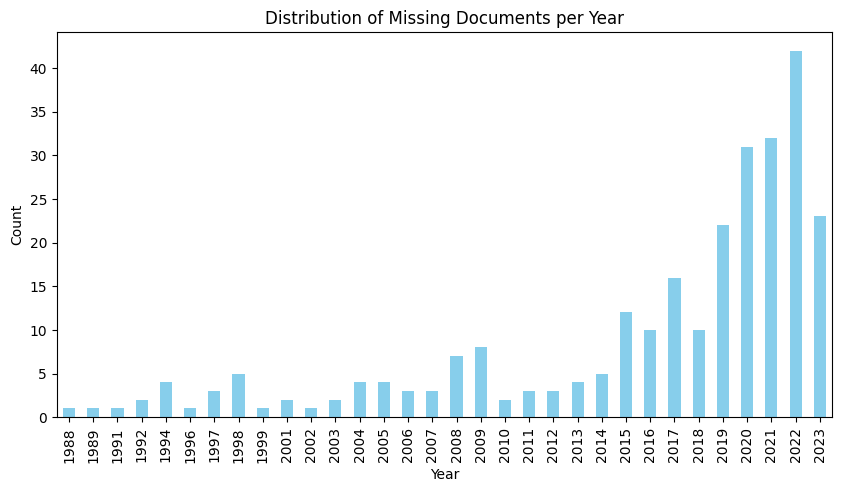

In [113]:
# Get the distribution of documents per year
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
ref_doi_df["year"].value_counts().sort_index().plot(kind="bar", color="skyblue")
plt.title("Distribution of Missing Documents per Year")
plt.xlabel("Year")
plt.ylabel("Count")